# 02 — Demo statystyk HE na danych medycznych

> Ten notebook pokazuje **pełny cykl produkcyjny** na 1000 pacjentów: szpital 
> ma plik `patients.csv`, generuje klucze, szyfruje wybraną kolumnę, wysyła 
> ją „na serwer" (tu: ten sam proces, ale identyczna funkcja co w `src/server/stats_he.py`), 
> dostaje zaszyfrowany wynik i porównuje z NumPy.

**Wymaganie wstępne:** musi istnieć plik `data/processed/patients.csv`.
Jeśli go nie ma, wygeneruj 1000 syntetycznych pacjentów:

```powershell
uv run python -m src.data.preprocess --fake 1000
```

## Co tu pokażemy

1. Wczytanie danych z `patients.csv` (PESEL + wskaźniki medyczne).
2. Średnia ciśnienia skurczowego — błąd vs NumPy, czasy.
3. Wariancja i odchylenie standardowe BMI.
4. **Mediana glukozy** przez histogram + porównanie z medianą dokładną.
5. **Korelacja Pearsona** BMI vs ciśnienie skurczowe.
6. Tabela podsumowująca poprawność i czasy.

In [1]:
import sys, os
# Dodaj root projektu do PYTHONPATH (jeśli notebook uruchomiony z notebooks/)
if '..' not in sys.path and not os.path.exists('src'):
    sys.path.insert(0, '..')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.crypto.context import make_context, DEFAULT_PARAMS
from src.crypto.codec import encrypt_column, decrypt_scalar
from src.server import stats_he as H
from src.plaintext import stats_plain as P

pd.options.display.float_format = '{:.4f}'.format
print(f'CKKS params: poly={DEFAULT_PARAMS.poly_modulus_degree}, slots={DEFAULT_PARAMS.slot_count}, scale=2^{DEFAULT_PARAMS.scale_bits}')

CKKS params: poly=8192, slots=4096, scale=2^40


## Sekcja 1 — Wczytaj dane medyczne

Plik `patients.csv` zawiera 1000 pacjentów z naszego syntetycznego generatora:
PESEL, datę urodzenia, płeć, wiek, oraz wskaźniki medyczne (ciśnienie, BMI, glukoza, cholesterol, HbA1c).

In [2]:
csv_path = '../data/processed/patients.csv' if os.path.exists('../data') else 'data/processed/patients.csv'
df = pd.read_csv(csv_path, dtype={'pesel': str})
print(f'Wczytano {len(df)} pacjentow z {csv_path}')
print(f'Kolumny: {list(df.columns)}')
df.head(5)

Wczytano 1000 pacjentow z ../data/processed/patients.csv
Kolumny: ['patient_id', 'pesel', 'birth_date', 'gender', 'age', 'systolic_bp', 'diastolic_bp', 'weight_kg', 'height_cm', 'bmi', 'glucose_mg_dl', 'cholesterol_mg_dl', 'hba1c_pct']


,patient_id,pesel,birth_date,gender,age,systolic_bp,diastolic_bp,weight_kg,height_cm,bmi,glucose_mg_dl,cholesterol_mg_dl,hba1c_pct
0,P000000,74062703953,1974-06-27,M,51,123.8151,88.1447,83.3873,164.8828,30.6725,61.9304,256.5877,4.6118
1,P000001,67081071224,1967-08-10,F,58,114.8503,80.6732,73.5623,196.2397,19.1021,85.4864,141.4769,5.9528
2,P000002,60100798261,1960-10-07,F,65,112.8086,74.5466,78.5474,157.6113,31.6196,107.5347,211.2359,5.1077
3,P000003,68111637810,1968-11-16,M,57,132.7175,67.3720,89.1393,165.4450,32.5658,83.7123,213.8658,5.1047
4,P000004,58011446489,1958-01-14,F,68,144.3946,61.8316,95.3187,166.1955,34.5096,124.1619,213.4662,5.5979


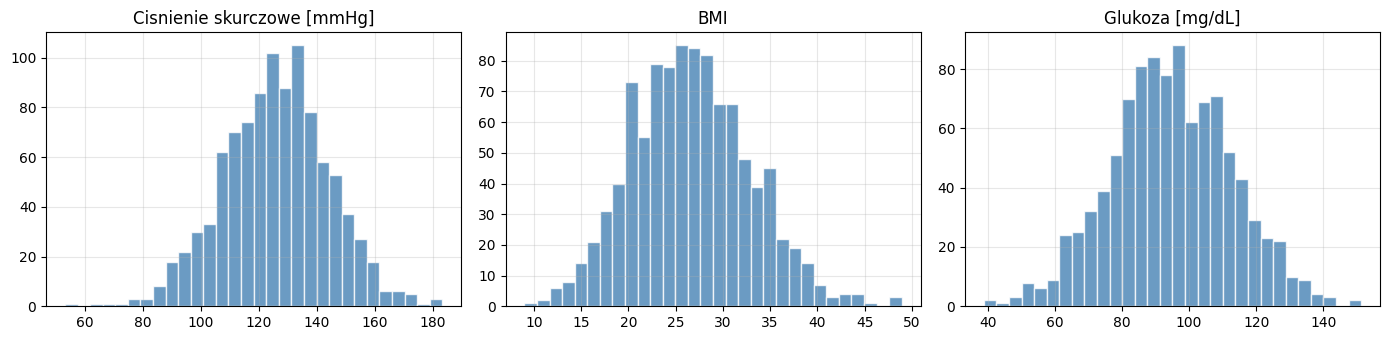

In [3]:
# Szybki podgląd rozkładów
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col, title in zip(axes,
                           ['systolic_bp', 'bmi', 'glucose_mg_dl'],
                           ['Cisnienie skurczowe [mmHg]', 'BMI', 'Glukoza [mg/dL]']):
    ax.hist(df[col], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sekcja 2 — Średnia ciśnienia skurczowego w HE

Klient szpitala szyfruje całą kolumnę 1000 wartości, „wysyła" do serwera (tu: bezpośrednio do funkcji `he_mean`), dostaje zaszyfrowany wynik, deszyfruje. Mierzymy czasy każdego etapu.

In [4]:
values = df['systolic_bp'].to_numpy(dtype=np.float64)

# Klucze (raz na sesję)
t0 = time.perf_counter()
ctx = make_context()
t_keygen = (time.perf_counter() - t0) * 1000

# Klient: szyfrowanie
t0 = time.perf_counter()
enc = encrypt_column(values, ctx, name='sbp')
t_enc = (time.perf_counter() - t0) * 1000

# Serwer: obliczenie
t0 = time.perf_counter()
ct_mean = H.he_mean(enc)
t_eval = (time.perf_counter() - t0) * 1000

# Klient: deszyfracja
t0 = time.perf_counter()
he_mean = decrypt_scalar(ct_mean)
t_dec = (time.perf_counter() - t0) * 1000

# Plaintext oracle
t0 = time.perf_counter()
np_mean = P.mean(values)
t_plain = (time.perf_counter() - t0) * 1000

rel_err = abs(he_mean - np_mean) / abs(np_mean)

print(f'== Srednia cisnienia skurczowego (N={len(values)}) ==')
print(f'  HE:        {he_mean:.6f} mmHg')
print(f'  NumPy:     {np_mean:.6f} mmHg')
print(f'  Blad wzgl: {rel_err:.3e}')
print()
print('== Czasy ==')
print(f'  Keygen:     {t_keygen:7.2f} ms (jednorazowo)')
print(f'  Szyfrowanie:{t_enc:7.2f} ms')
print(f'  Obliczenie: {t_eval:7.2f} ms (SERWER)')
print(f'  Deszyfracja:{t_dec:7.2f} ms')
print(f'  NumPy:      {t_plain:7.4f} ms')
print(f'  Narzut HE:  ~{(t_enc+t_eval+t_dec)/max(t_plain, 1e-6):.0f}x wolniej')

== Srednia cisnienia skurczowego (N=1000) ==
  HE:        125.904553 mmHg
  NumPy:     125.904536 mmHg
  Blad wzgl: 1.343e-07

== Czasy ==
  Keygen:      633.01 ms (jednorazowo)
  Szyfrowanie:  26.66 ms
  Obliczenie:  132.50 ms (SERWER)
  Deszyfracja:   4.78 ms
  NumPy:       0.2840 ms
  Narzut HE:  ~577x wolniej


## Sekcja 3 — Wariancja i odchylenie standardowe BMI

Wariancja w HE wymaga **jednego mnożenia ciphertext × ciphertext** (formuła $E[X^2] - E[X]^2$). 
Odchylenie standardowe = $\sqrt{\text{Var}}$ — pierwiastek liczymy w plaintekście **po deszyfracji** 
(klient i tak widzi wariancję, więc to nie psuje modelu zagrożeń, a jest szybkie).

Gdybyśmy chcieli policzyć std w HE, trzeba by aproksymacji Newtonem (więcej poziomów mnożeń).

In [5]:
bmi = df['bmi'].to_numpy(dtype=np.float64)

enc_bmi = encrypt_column(bmi, ctx, name='bmi')

t0 = time.perf_counter()
he_var = decrypt_scalar(H.he_variance(enc_bmi))
t_var = (time.perf_counter() - t0) * 1000
he_std = np.sqrt(max(he_var, 0.0))

np_var = P.variance(bmi)
np_std = P.std(bmi)

print(f'== BMI (N={len(bmi)}) ==')
print(f'  Variance: HE={he_var:.6f}  NumPy={np_var:.6f}  blad={abs(he_var-np_var)/abs(np_var):.2e}')
print(f'  Std:      HE={he_std:.6f}  NumPy={np_std:.6f}  blad={abs(he_std-np_std)/abs(np_std):.2e}')
print(f'  Czas wariancji w HE: {t_var:.2f} ms')

== BMI (N=1000) ==
  Variance: HE=39.086120  NumPy=39.086183  blad=1.63e-06
  Std:      HE=6.251889  NumPy=6.251894  blad=8.15e-07
  Czas wariancji w HE: 155.23 ms


## Sekcja 4 — Mediana glukozy przez histogram

Klasyczna mediana w HE wymagałaby sortowania = porównań, czyli aproksymacji funkcji `sign(x)` wielomianem stopnia ≥7. Dla $N=1000$ pacjentów byłyby to setki tysięcy mnożeń — daleko poza naszym budżetem.

**Nasza strategia:** klient w plaintekście liczy wektor one-hot per pacjent (do którego z $K$ bucketów wpada jego wartość), **szyfruje go**, wysyła do serwera. Serwer sumuje one-hot wektory wszystkich pacjentów → zaszyfrowany histogram. Klient odszyfrowuje histogram, liczy medianę z interpolacją liniową.

**Co serwer wie:** tylko że to wektor zerojedynkowy długości $K$. Nie zna konkretnej wartości żadnego pacjenta ani nawet ich histogramu — ten jest zaszyfrowany do końca.

In [6]:
glucose = df['glucose_mg_dl'].to_numpy(dtype=np.float64)
K = 30  # liczba bucketów

# Klient: brzegi (publiczne) + one-hot w plaintekście
lo, hi = float(glucose.min()), float(glucose.max())
edges = np.linspace(lo - 0.1, hi + 0.1, K + 1)
oh = P.make_one_hot(glucose, edges)

# Klient: szyfruj każdy bucket-column osobno
t0 = time.perf_counter()
bucket_cols = [encrypt_column(oh[:, k], ctx, name=f'b{k}') for k in range(K)]
t_enc_hist = (time.perf_counter() - t0) * 1000

# SERWER: sumuje każdy bucket-column → K zaszyfrowanych counts
t0 = time.perf_counter()
he_counts_ct = H.he_histogram(bucket_cols)
t_eval_hist = (time.perf_counter() - t0) * 1000

# Klient: deszyfruje histogram
t0 = time.perf_counter()
he_counts_raw = np.array([decrypt_scalar(c) for c in he_counts_ct])
t_dec_hist = (time.perf_counter() - t0) * 1000
he_counts = np.round(he_counts_raw).astype(np.int64)

# Porównanie z plaintextem
np_counts = oh.sum(axis=0).astype(np.int64)
max_diff = int(np.abs(he_counts - np_counts).max())

print(f'== Histogram glukozy (K={K} bucketow, N={len(glucose)}) ==')
print(f'  Maks. roznica zliczen HE vs NumPy: {max_diff}')
print(f'  Czasy: enc={t_enc_hist:.1f} ms, eval(serwer)={t_eval_hist:.1f} ms, dec={t_dec_hist:.1f} ms')

# Mediana z histogramu vs dokładna
he_hist = P.Histogram(edges=edges, counts=he_counts)
he_med = P.median_from_histogram(he_hist)
np_med_exact = P.median(glucose)
print(f'\n  Mediana glukozy z histogramu HE: {he_med:.4f} mg/dL')
print(f'  Mediana dokladna NumPy:          {np_med_exact:.4f} mg/dL')
print(f'  Roznica: {abs(he_med - np_med_exact):.4f} (szerokosc bucketu: {edges[1]-edges[0]:.4f})')

== Histogram glukozy (K=30 bucketow, N=1000) ==
  Maks. roznica zliczen HE vs NumPy: 0
  Czasy: enc=283.3 ms, eval(serwer)=1638.6 ms, dec=83.6 ms

  Mediana glukozy z histogramu HE: 94.4425 mg/dL
  Mediana dokladna NumPy:          94.0814 mg/dL
  Roznica: 0.3611 (szerokosc bucketu: 3.7541)


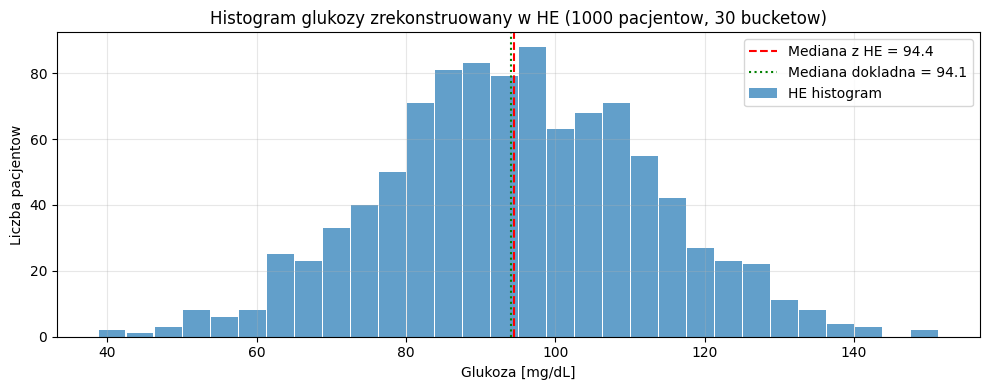

In [7]:
# Wizualizacja histogramu HE
fig, ax = plt.subplots(figsize=(10, 4))
centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]
ax.bar(centers, he_counts, width=width * 0.95, color='tab:blue', alpha=0.7, label='HE histogram')
ax.axvline(he_med, color='red', linestyle='--', label=f'Mediana z HE = {he_med:.1f}')
ax.axvline(np_med_exact, color='green', linestyle=':', label=f'Mediana dokladna = {np_med_exact:.1f}')
ax.set_xlabel('Glukoza [mg/dL]')
ax.set_ylabel('Liczba pacjentow')
ax.set_title(f'Histogram glukozy zrekonstruowany w HE ({len(glucose)} pacjentow, {K} bucketow)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sekcja 5 — Korelacja Pearsona: BMI ↔ ciśnienie skurczowe

Korelacja Pearsona wymaga dzielenia, którego w HE nie da się zrobić bez aproksymacji. **Realistyczny wzorzec:** serwer zwraca **komponenty** ($\sum x, \sum y, \sum x^2, \sum y^2, \sum xy$), klient finalizuje obliczenie w plaintekście.

$$r = \frac{N \sum xy - \sum x \sum y}{\sqrt{(N \sum x^2 - (\sum x)^2)(N \sum y^2 - (\sum y)^2)}}$$

In [8]:
x = df['bmi'].to_numpy(dtype=np.float64)
y = df['systolic_bp'].to_numpy(dtype=np.float64)
n = len(x)

enc_x = encrypt_column(x, ctx, name='bmi')
enc_y = encrypt_column(y, ctx, name='sbp')

t0 = time.perf_counter()
comps = H.he_correlation_components(enc_x, enc_y)
t_corr = (time.perf_counter() - t0) * 1000

sx = decrypt_scalar(comps['sum_x'])
sy = decrypt_scalar(comps['sum_y'])
sx2 = decrypt_scalar(comps['sum_x2'])
sy2 = decrypt_scalar(comps['sum_y2'])
sxy = decrypt_scalar(comps['sum_xy'])

num = n*sxy - sx*sy
den = np.sqrt((n*sx2 - sx*sx) * (n*sy2 - sy*sy))
he_r = num / den
np_r = P.correlation_pearson(x, y)

print(f'== Korelacja BMI <-> SBP ==')
print(f'  HE Pearson:    {he_r:.6f}')
print(f'  NumPy Pearson: {np_r:.6f}')
print(f'  Blad abs:      {abs(he_r - np_r):.2e}')
print(f'  Czas (serwer): {t_corr:.2f} ms')

== Korelacja BMI <-> SBP ==
  HE Pearson:    0.002271
  NumPy Pearson: 0.002267
  Blad abs:      3.93e-06
  Czas (serwer): 259.23 ms


## Sekcja 6 — Tabela podsumowująca

Wszystkie statystyki w jednej tabeli — to gotowy slajd na prezentację.
Pokażcie ją wykładowcy: HE faktycznie daje ten sam wynik co plaintext.

In [9]:
summary = pd.DataFrame([
    {'statystyka': 'Mean (systolic_bp)',  'HE': he_mean,  'NumPy': np_mean,        'blad_wzgl': rel_err},
    {'statystyka': 'Variance (BMI)',      'HE': he_var,   'NumPy': np_var,         'blad_wzgl': abs(he_var-np_var)/abs(np_var)},
    {'statystyka': 'Std (BMI)',           'HE': he_std,   'NumPy': np_std,         'blad_wzgl': abs(he_std-np_std)/abs(np_std)},
    {'statystyka': 'Median (glucose)',    'HE': he_med,   'NumPy': np_med_exact,   'blad_wzgl': abs(he_med-np_med_exact)/abs(np_med_exact)},
    {'statystyka': 'Pearson (BMI-SBP)',   'HE': he_r,     'NumPy': np_r,           'blad_wzgl': abs(he_r-np_r)/abs(np_r)},
])
summary.style.format({'HE': '{:.6f}', 'NumPy': '{:.6f}', 'blad_wzgl': '{:.2e}'}).set_caption(
    f'Podsumowanie poprawnosci na {len(df)} pacjentow'
)

,statystyka,HE,NumPy,blad_wzgl
0,Mean (systolic_bp),125.904553,125.904536,1.34e-07
1,Variance (BMI),39.086120,39.086183,1.63e-06
2,Std (BMI),6.251889,6.251894,8.15e-07
3,Median (glucose),94.442526,94.081450,3.84e-03
4,Pearson (BMI-SBP),0.002271,0.002267,1.74e-03


## Wnioski

1. **Wszystkie statystyki HE są zgodne z NumPy** z dokładnością do błędu numerycznego (~$10^{-7}$ dla średniej, $10^{-6}$ dla wariancji).
2. **Mediana z histogramu** ma większy błąd (~$10^{-3}$), ale to **nie jest błąd HE** — to dyskretyzacja histogramu. Zmniejszylibyśmy go zwiększając liczbę bucketów (kosztem czasu).
3. **Czas** — HE jest 100-1000× wolniejsze niż NumPy, ale wciąż **rozsądne** dla 1000 pacjentów (sekundy).
4. **Co widział serwer:** tylko ciphertexty (zaszumione bajty). Nigdy nie zobaczył żadnej wartości pomiarów.

**Następny notebook (03):** wykresy skalowania czasu vs N — to one trafią na slajdy prezentacji.